<a href="https://colab.research.google.com/github/pgita4677-jpg/my-app/blob/main/UAS_Kel2_gitarezalatip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install split-folders tensorflow matplotlib ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.6 MB/s eta 0:00:00


In [2]:
!apt-get update
!apt-get install unrar
!unrar x dataset.rar

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,640 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,883 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,971 kB]
Get:14 http://secu

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
df = pd.read_excel('data_rekam_medis_clean.xlsx')

In [5]:
df.tail(5) #cek is data pada  5 baris awal

,no_rm,sistolik,diastolik,nadi,respirasi,suhu,spo2,sakit_kepala,pusing,mudah_lelah,...,batuk_berdahak,demam,nyeri_perut,mual,muntah,nyeri_tenggorokan,lemas,anamnesa,diagnosa,pemeriksaan_penunjang
295,103373.0,90,60.0,`130,23,"38,6",97.0,0,0,0,...,1,1,0,0,0,0,0,"sesak 4 - 7 hari, batuk berdahak selama 3 bula...",TUBERCOLOSIS PARU,terlampir
296,94787.0,90,60.0,113,23,"38,5",95.0,0,0,0,...,1,1,0,0,0,0,0,"sesak 4 - 7 hari, batuk berdahak selama 3 bula...",TUBERCOLOSIS PARU,terlampir
297,103397.0,80,60.0,85,21,38,97.0,0,0,0,...,1,1,0,0,0,0,0,"sesak 4 - 7 hari, batuk berdahak selama 3 bula...",TUBERCOLOSIS PARU,terlampir
298,88197.0,180,90.0,108,20,"39,1",98.0,0,0,0,...,1,1,0,0,0,0,0,"sesak 4 - 7 hari, batuk berdahak selama 3 bula...",TUBERCOLOSIS PARU,terlampir
299,103387.0,140,90.0,116,20,38,98.0,0,0,0,...,1,1,0,0,0,0,0,"sesak 4 - 7 hari, batuk berdahak selama 3 bula...",TUBERCOLOSIS PARU,terlampir


In [6]:
df.describe() #cek deskripsi data

,no_rm,diastolik,respirasi,spo2,sakit_kepala,pusing,mudah_lelah,sesak_nafas,batuk_berdahak,demam,nyeri_perut,mual,muntah,nyeri_tenggorokan,lemas
count,200.000000,273.000000,300.000000,298.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.0,300.0,300.0,300.0,300.0
mean,76106.450000,77.091575,20.703333,95.822148,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.0,0.0,0.0,0.0,0.0
std,38014.731853,9.112594,4.265674,5.460471,0.472192,0.472192,0.472192,0.472192,0.472192,0.472192,0.0,0.0,0.0,0.0,0.0
min,294.000000,41.000000,12.000000,52.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,38577.750000,71.000000,19.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
50%,97719.000000,79.000000,20.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
75%,104606.500000,80.000000,23.000000,99.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0
max,196472.000000,110.000000,39.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0


In [7]:
df.isnull().sum() #cek missing value pada setiap kolom

,0
no_rm,100
sistolik,27
diastolik,27
nadi,0
respirasi,0
suhu,0
spo2,2
sakit_kepala,0
pusing,0
mudah_lelah,0


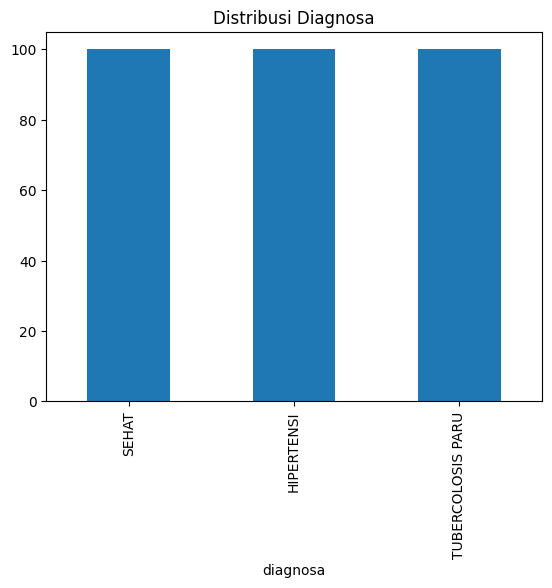

In [8]:
df['diagnosa'].value_counts().plot(kind='bar')
plt.title('Distribusi Diagnosa')
plt.show()

In [9]:
df = df.drop(columns=['no_rm','anamnesa','pemeriksaan_penunjang'], errors='ignore')

In [11]:
df['sistolik'] = pd.to_numeric(df['sistolik'], errors='coerce') #ubah tipe data kedalam tipe data numerik
median_sistolik = df['sistolik'].median()
df['sistolik'] = df['sistolik'].fillna(median_sistolik)

df['diastolik'] = pd.to_numeric(df['diastolik'], errors='coerce')
median_diastolik = df['diastolik'].median()
df['diastolik'] = df['diastolik'].fillna(median_diastolik);

df['spo2'] = pd.to_numeric(df['spo2'], errors='coerce')
median_spo2 = df['spo2'].median()
df['spo2'] = df['spo2'].fillna(median_spo2);

df['nadi'] = pd.to_numeric(df['nadi'], errors='coerce')
median_nadi = df['nadi'].median()
df['nadi'] = df['nadi'].fillna(median_nadi);

In [12]:
df['suhu'] = df['suhu'].astype(str).str.replace(',', '.', regex=False)
df['suhu'] = pd.to_numeric(df['suhu'], errors='coerce')
# Fill any NaNs that resulted from the coercion (e.g., if 'suhu' string was found)
median_suhu = df['suhu'].median()
df['suhu'] = df['suhu'].fillna(median_suhu)

Kolom gejala yang digunakan:

*   sakit_kepala
*   pusing
*   mudah_lelah
*   sesak_nafas
*   batuk_berdahak
*   demam
*   nyeri_perut
*   mual
*   muntah
*   nyeri_tenggorokan
*   lemas

Pastikan semua bernilai 0 atau 1. dimana 0 untuk tidak merasakan gejala dan 1 untuk merakasan gejala

In [13]:
df.describe()

,sistolik,diastolik,nadi,respirasi,suhu,spo2,sakit_kepala,pusing,mudah_lelah,sesak_nafas,batuk_berdahak,demam,nyeri_perut,mual,muntah,nyeri_tenggorokan,lemas
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.0,300.0,300.0,300.0,300.0
mean,119.580000,77.263333,77.433333,20.703333,37.308333,95.830000,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.0,0.0,0.0,0.0,0.0
std,21.630144,8.708623,43.788854,4.265674,1.148023,5.443025,0.472192,0.472192,0.472192,0.472192,0.472192,0.472192,0.0,0.0,0.0,0.0,0.0
min,40.000000,41.000000,20.000000,12.000000,30.000000,52.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,108.000000,72.000000,22.000000,19.000000,36.175000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
50%,116.000000,79.000000,90.000000,20.000000,37.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
75%,120.000000,80.000000,110.000000,23.000000,38.100000,99.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0
max,200.000000,110.000000,196.000000,39.000000,40.500000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0


In [14]:
symptom_cols = ['sistolik','diastolik','nadi','respirasi','suhu','spo2',
    'sakit_kepala','pusing','mudah_lelah','sesak_nafas',
    'batuk_berdahak','demam','nyeri_perut','mual','muntah',
    'nyeri_tenggorokan','lemas']
df[symptom_cols] = df[symptom_cols].fillna(0)

In [15]:
# Standardize the 'diagnosa' column before mapping to handle inconsistencies
df['diagnosa'] = df['diagnosa'].astype(str).str.strip().str.upper()

# Now, apply the mapping with uppercase keys
df['diagnosa'] = df['diagnosa'].map({
    'SEHAT':0,
    'HIPERTENSI':1,
    'TUBERCOLOSIS PARU':2,

})


In [16]:
X = df.drop(columns=['diagnosa'])
y = df['diagnosa']


X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

print("Jumlah data:", len(df))
print("Jumlah fitur:", len(X.columns))
print("Jumlah label:", X.columns)
print("Jumlah label:", len(y.unique()))
print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))

Jumlah data: 300
Jumlah fitur: 17
Jumlah label: Index(['sistolik', 'diastolik', 'nadi', 'respirasi', 'suhu', 'spo2',
       'sakit_kepala', 'pusing', 'mudah_lelah', 'sesak_nafas',
       'batuk_berdahak', 'demam', 'nyeri_perut', 'mual', 'muntah',
       'nyeri_tenggorokan', 'lemas'],
      dtype='object')
Jumlah label: 3
Jumlah data latih: 240
Jumlah data uji: 60


In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [19]:
y_pred = model.predict(X_test)

#metrik evaluasi (confusion matrix)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        22

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



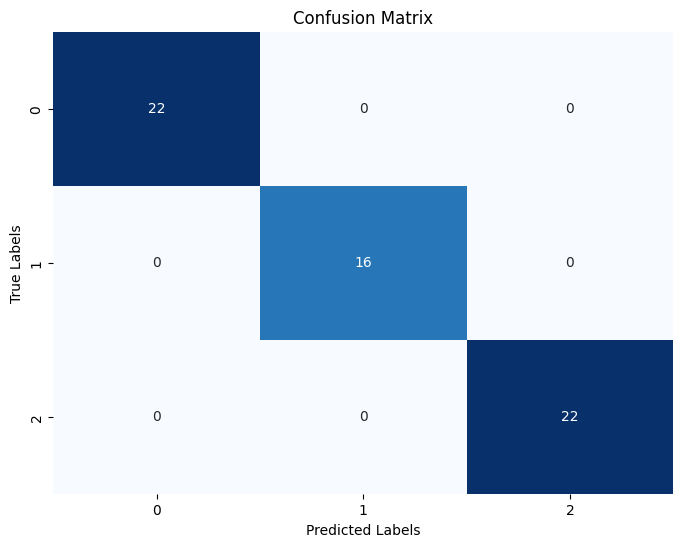

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [21]:
def predict_new_patient_diagnosis(new_patient_data):
    # Ensure the input is a DataFrame with the same column order as X
    feature_columns = X.columns # Get the column names from the original training features
    new_df = pd.DataFrame([new_patient_data], columns=feature_columns)

    # Scale the new data using the SAME StandardScaler fitted on the training data
    new_scaled_data = scaler.transform(new_df)

    # Make a prediction
    prediction_numeric = model.predict(new_scaled_data)

    # Map the numeric prediction back to the original diagnosis label
    reverse_diagnosis_map = {
        0: 'SEHAT',
        1: 'HIPERTENSI',
        2: 'TUBERCOLOSIS PARU',
    }
    predicted_diagnosis = reverse_diagnosis_map.get(prediction_numeric[0], 'Unknown')

    return predicted_diagnosis


In [23]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model dan scaler berhasil disimpan")

✅ Model dan scaler berhasil disimpan


In [24]:
new_patient_input = {}
feature_columns = X.columns

print("Masukkan data pasien baru:")
for col in feature_columns:
    while True:
        try:
            if col in ['sistolik', 'diastolik', 'nadi', 'respirasi', 'suhu', 'spo2']:
                value = float(input(f"Masukkan nilai untuk {col}: "))
            else: # Binary features
                value = int(input(f"Apakah pasien merasakan {col}? (0 untuk Tidak, 1 untuk Ya): "))
                if value not in [0, 1]:
                    raise ValueError("Input harus 0 atau 1.")
            new_patient_input[col] = value
            break
        except ValueError:
            print("Input tidak valid. Harap masukkan nilai numerik yang benar atau 0/1 untuk gejala.")

predicted_diag_from_input = predict_new_patient_diagnosis(new_patient_input)
print(f"\nPrediksi Diagnosis untuk pasien dengan input tersebut adalah: {predicted_diag_from_input}")

Masukkan data pasien baru:
Masukkan nilai untuk sistolik: 140
Masukkan nilai untuk diastolik: 90
Masukkan nilai untuk nadi: 24
Masukkan nilai untuk respirasi: 22
Masukkan nilai untuk suhu: 39
Masukkan nilai untuk spo2: 99
Apakah pasien merasakan sakit_kepala? (0 untuk Tidak, 1 untuk Ya): 1
Apakah pasien merasakan pusing? (0 untuk Tidak, 1 untuk Ya): 1
Apakah pasien merasakan mudah_lelah? (0 untuk Tidak, 1 untuk Ya): 1
Apakah pasien merasakan sesak_nafas? (0 untuk Tidak, 1 untuk Ya): 1
Apakah pasien merasakan batuk_berdahak? (0 untuk Tidak, 1 untuk Ya): 
Input tidak valid. Harap masukkan nilai numerik yang benar atau 0/1 untuk gejala.
Apakah pasien merasakan batuk_berdahak? (0 untuk Tidak, 1 untuk Ya): 0
Apakah pasien merasakan demam? (0 untuk Tidak, 1 untuk Ya): 0
Apakah pasien merasakan nyeri_perut? (0 untuk Tidak, 1 untuk Ya): 0
Apakah pasien merasakan mual? (0 untuk Tidak, 1 untuk Ya): 0
Apakah pasien merasakan muntah? (0 untuk Tidak, 1 untuk Ya): 1
Apakah pasien merasakan nyeri_ten